# GSoC 2026 NeuroDyads — Brain-to-Brain Decoder Pre-Task
**ML4SCI | Dr. Evie Malaia & Dr. Brendan Ames**

 Submitted by: Debarpita Dash

In [1]:
!pip install mne cebra torch scikit-learn matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.8/251.8 kB 21.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
from cebra import CEBRA
import torch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from matplotlib.lines import Line2D

EDF_A = '/content/Listener.edf'
EDF_B = '/content/Speaker.edf'

## Part 1 — Preprocessing

### Step 1: Load and inspect the files

Before doing anything, I wanted to check what the annotations actually look like in these files.

In [5]:
raw_A = mne.io.read_raw_edf(EDF_A, preload=True, verbose=False)
raw_B = mne.io.read_raw_edf(EDF_B, preload=True, verbose=False)

# print all annotations first — good to see what's actually in the file
print("Participant A annotations")
for ann in raw_A.annotations:
    print(f"  '{ann['description']}'  onset={ann['onset']:.2f}s")

print("Participant B annotations")
for ann in raw_B.annotations:
    print(f"  '{ann['description']}'  onset={ann['onset']:.2f}s")

print(f"\nA duration: {raw_A.times[-1]:.1f}s | channels: {raw_A.info['nchan']}")
print(f"B duration: {raw_B.times[-1]:.1f}s | channels: {raw_B.info['nchan']}")

Participant A annotations
  'DIN1'  onset=1.00s
  'DIN1'  onset=148.78s
  'DIN1'  onset=149.05s
Participant B annotations
  'VBeg'  onset=0.71s
  'DIN1'  onset=0.79s
  'DIN1'  onset=148.56s
  'DIN1'  onset=148.84s
  'VEnd'  onset=302.43s

A duration: 303.0s | channels: 65
B duration: 303.0s | channels: 65


A few things worth noting from the output:
- A has exactly 3 DIN1 markers as expected. B also has 3 DIN1s but additionally has VBeg/VEnd markers.
- The markers are slightly offset between A and B (~0.2s). This is a clock drift between the two recording systems, which is normal in dual-EEG setups. Because of this I crop each file using its own marker times rather than a shared average, otherwise we'd be misaligning by a few samples.


### Step 2: Segment the data

CEBRA needs the two participants' signals to be temporally aligned due to which cropping is essential. If we include extra baseline or inter-block padding, the joint signal won't reflect the actual conversation and any structure CEBRA finds would be an artifact of misalignment.

In [6]:
# pull out the 3 DIN1 onset times from each file
def get_din1_onsets(raw):
    onsets = [ann['onset'] for ann in raw.annotations if ann['description'] == 'DIN1']
    onsets.sort()
    assert len(onsets) == 3, f"Expected 3 DIN1 markers, got {len(onsets)}: {onsets}"
    return onsets

din_A = get_din1_onsets(raw_A)
din_B = get_din1_onsets(raw_B)

print(f"A DIN1 onsets: {din_A}")
print(f"B DIN1 onsets: {din_B}")

A DIN1 onsets: [np.float64(1.005), np.float64(148.778), np.float64(149.052)]
B DIN1 onsets: [np.float64(0.788), np.float64(148.561), np.float64(148.835)]


In [7]:
# crop each file using its own marker times to handle the ~0.2s clock drift
# positive affect: DIN1[0] -> DIN1[1]
# negative affect: DIN1[2] -> end of file

t_end_A = raw_A.times[-1]
t_end_B = raw_B.times[-1]

pos_A = raw_A.copy().crop(tmin=din_A[0], tmax=din_A[1])
pos_B = raw_B.copy().crop(tmin=din_B[0], tmax=din_B[1])

neg_A = raw_A.copy().crop(tmin=din_A[2], tmax=t_end_A)
neg_B = raw_B.copy().crop(tmin=din_B[2], tmax=t_end_B)

print(f"Positive segment — A: {pos_A.times[-1]:.2f}s | B: {pos_B.times[-1]:.2f}s")
print(f"Negative segment — A: {neg_A.times[-1]:.2f}s | B: {neg_B.times[-1]:.2f}s")

Positive segment — A: 147.77s | B: 147.77s
Negative segment — A: 153.94s | B: 154.16s


### Step 3: Drop VREF (channel 65)

Channel 65 is the vertex reference electrode. Leaving it in would add a near-constant signal that ICA might pick up as a component, which wastes decomposition capacity.

In [8]:
vref_name_A = raw_A.ch_names[64]
vref_name_B = raw_B.ch_names[64]
print(f"Dropping VREF — A: '{vref_name_A}' | B: '{vref_name_B}'")

for seg in [pos_A, pos_B, neg_A, neg_B]:
    vref = seg.ch_names[64]
    seg.drop_channels([vref])

print(f"Channels after drop: {pos_A.info['nchan']}")

Dropping VREF — A: 'EEG VREF' | B: 'EEG VREF'
Channels after drop: 64


### Step 4: Bandpass filter (1–40 Hz)

The data is already hardware-filtered to 0.1–45 Hz, but I'm tightening that slightly before ICA. The 1 Hz highpass is the important one as slow drifts below 1 Hz can look like independent components to ICA and eat into the 20 components we're fitting. Cutting at 40 Hz removes the filter rolloff region from the hardware filter without losing anything meaningful.

In [9]:
for seg in [pos_A, pos_B, neg_A, neg_B]:
    seg.filter(l_freq=1.0, h_freq=40.0, fir_window='hamming', verbose=False)

print(f"Sample rate: {pos_A.info['sfreq']} Hz")

Sample rate: 250.0 Hz


### Step 5: ICA artifact removal

Before running ICA, I needed to assign electrode locations as the EDF file doesn't have them embedded. I first checked what the channel names looked like in the data (turned out to be `EEG 1, EEG 2...`) and then matched them to the GSN-HydroCel-64_1.0 standard montage (which expects `E1, E2...`), renaming accordingly.

In [10]:
rename_dict = {f'EEG {i}': f'E{i}' for i in range(1, 65)}

for seg in [pos_A, pos_B, neg_A, neg_B]:
    seg.rename_channels(rename_dict)

print("Renamed — first 5:", pos_A.ch_names[:5])

Renamed — first 5: ['E1', 'E2', 'E3', 'E4', 'E5']


In [11]:
montage = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
for seg in [pos_A, pos_B, neg_A, neg_B]:
    seg.set_montage(montage, match_case=False, on_missing='warn')

print(f"Montage assigned — {len(montage.ch_names)} channels")
print(f"E1 location check: {pos_A.info['chs'][0]['loc'][:3]}")

Montage assigned — 64 channels
E1 location check: [0.06464045 0.06165288 0.00147742]


**Fitting ICA on Participant A (positive segment)**

Using 20 components enough to capture the main sources without overfitting noise. FastICA with logcosh is the standard choice here, nothing fancy. I fit ICA separately on each participant so the decomposition reflects that participant's own data.

In [12]:
ica = ICA(n_components=20, method='fastica', random_state=42, max_iter=1000)
ica.fit(pos_A)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 3.5s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,56 iterations on raw data (36944 samples)
ICA components,20
Available PCA components,64
Channel types,eeg
ICA components marked for exclusion,—


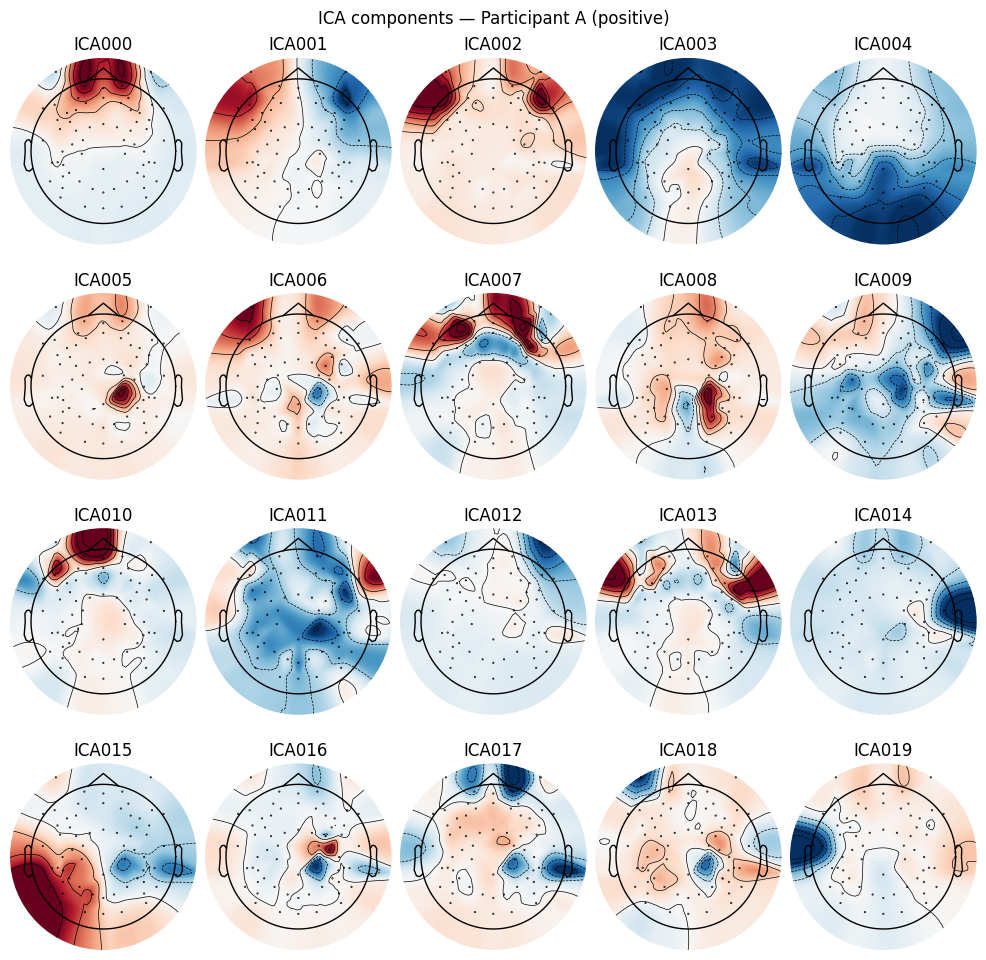

In [13]:
# look at the topographies to identify which components are artifacts
ica.plot_components(picks=range(20), title='ICA components — Participant A (positive)')
plt.show()

Creating RawArray with float64 data, n_channels=5, n_times=36944
    Range : 251 ... 37194 =      1.004 ...   148.776 secs
Ready.
Using matplotlib as 2D backend.


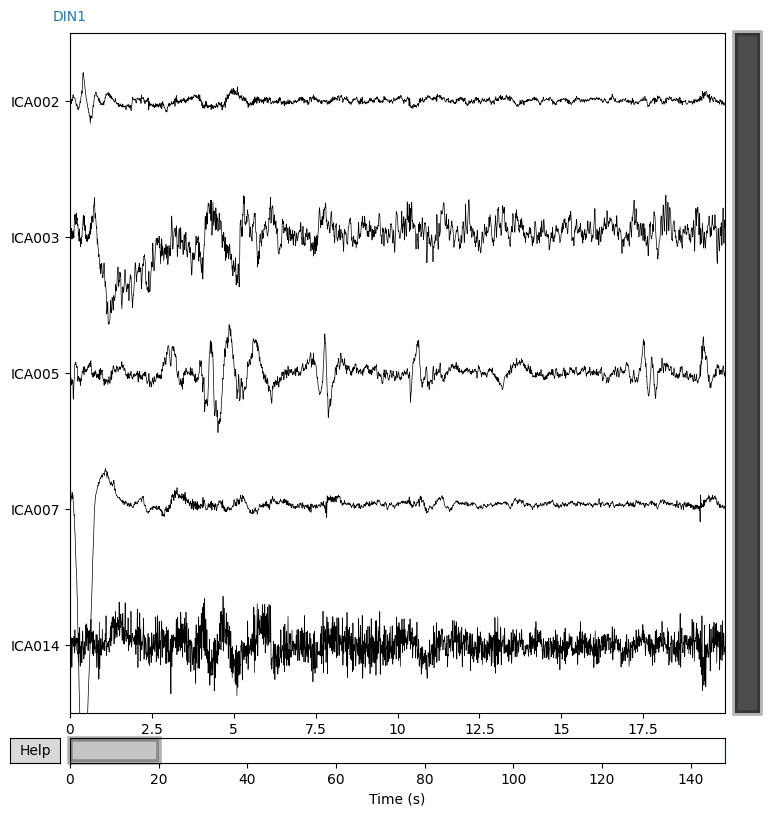

In [14]:
# confirm with time courses before rejecting
# looking for: slow large peaks (blinks), step-like jumps (saccades), sustained buzzing (muscle)
ica.plot_sources(pos_A, picks=[2, 3, 5, 7, 14],
                 title='Time courses — suspected artifacts (A)',
                 show=True)
plt.show()

**Component rejection — Participant A:**

- **ICA002:** The topography looks like a broad, almost uniform field across the scalp, and the time course has large spikes around ~2.5s and ~4s. This pattern is very typical of eye blinks, which tend to produce strong, widespread frontal activity that leaks across channels.

- **ICA003:** Shows spikes at the exact same time points as ICA002 but with opposite polarity. This is likely the same blink artifact being split across two components, which can happen with ICA. Removing both to be safe.

- **ICA005:** There is a very focal hotspot near the right temporal edge, and the time course has a slow drifting pattern. This kind of spatially localized activity at the edge is unlikely to be cortical and is more consistent with electrode noise or poor contact.

- **ICA007:** The topography is clearly left–right asymmetric over the frontal region, and the time course shows irregular bursts. This combination strongly suggests horizontal eye movements (saccades), where the asymmetry is a key indicator.

- **ICA014:** Displays a focal edge pattern along with very slow oscillations (~0.5 Hz) in the time course. The signal is both too slow and too spatially confined to be neural, pointing instead to electrode drift or low-frequency noise.

In [15]:
ica.exclude = [2, 3, 5, 7, 14]

clean_pos_A = ica.apply(pos_A.copy())
clean_neg_A = ica.apply(neg_A.copy())

print(f"Excluded: {ica.exclude}")
print("ICA applied to Participant A")

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 5 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 5 ICA components
    Projecting back using 64 PCA components
Excluded: [2, 3, 5, 7, 14]
ICA applied to Participant A


### PSD before vs after ICA — Participant A

Plotting the mean power spectrum across all channels before and after ICA to see what actually changed.

Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


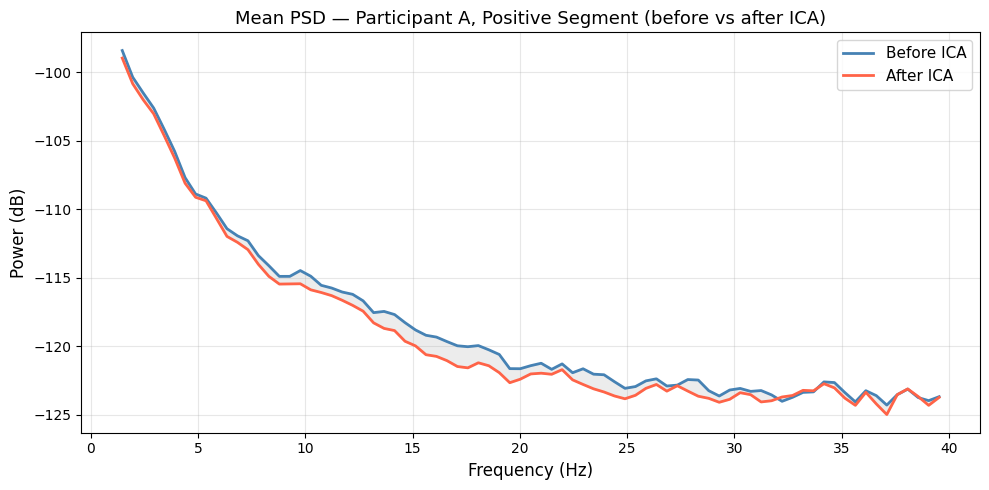

In [16]:
psd_before = pos_A.compute_psd(method='welch', fmin=1, fmax=40, n_fft=512)
psd_after  = clean_pos_A.compute_psd(method='welch', fmin=1, fmax=40, n_fft=512)

freqs = psd_before.freqs
mean_before = 10 * np.log10(psd_before.get_data().mean(axis=0))
mean_after  = 10 * np.log10(psd_after.get_data().mean(axis=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freqs, mean_before, color='steelblue', lw=2, label='Before ICA')
ax.plot(freqs, mean_after,  color='tomato',    lw=2, label='After ICA')
ax.fill_between(freqs, mean_before, mean_after, alpha=0.15, color='gray')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (dB)', fontsize=12)
ax.set_title('Mean PSD — Participant A, Positive Segment (before vs after ICA)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What changed and why:**

After applying ICA, the spectrum (red) is generally lower than before (blue), especially in the lower and mid-frequency ranges. A few things stand out:

- The reduction in the **1–5 Hz range** is expected. ICA002 and ICA003 were identified as eye blink components, and blinks tend to introduce large, slow fluctuations. Removing them naturally reduces power in the delta and theta bands.

- The biggest drop is in the **8–15 Hz range**. This is likely because components like ICA005 and ICA014, which looked like drift or electrode-related noise, were contributing broad low-frequency power that extended into this band.

- Beyond **20 Hz**, the two curves are quite similar. This is a good sign, since it suggests that higher-frequency neural signals have been preserved. If important brain activity had been removed by mistake, we would expect to see a noticeable drop here as well.

Overall, the characteristic 1/f shape of the spectrum is still intact. Proving that our neural signal has not been distorted.

**ICA — Participant B**

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 6.8s.


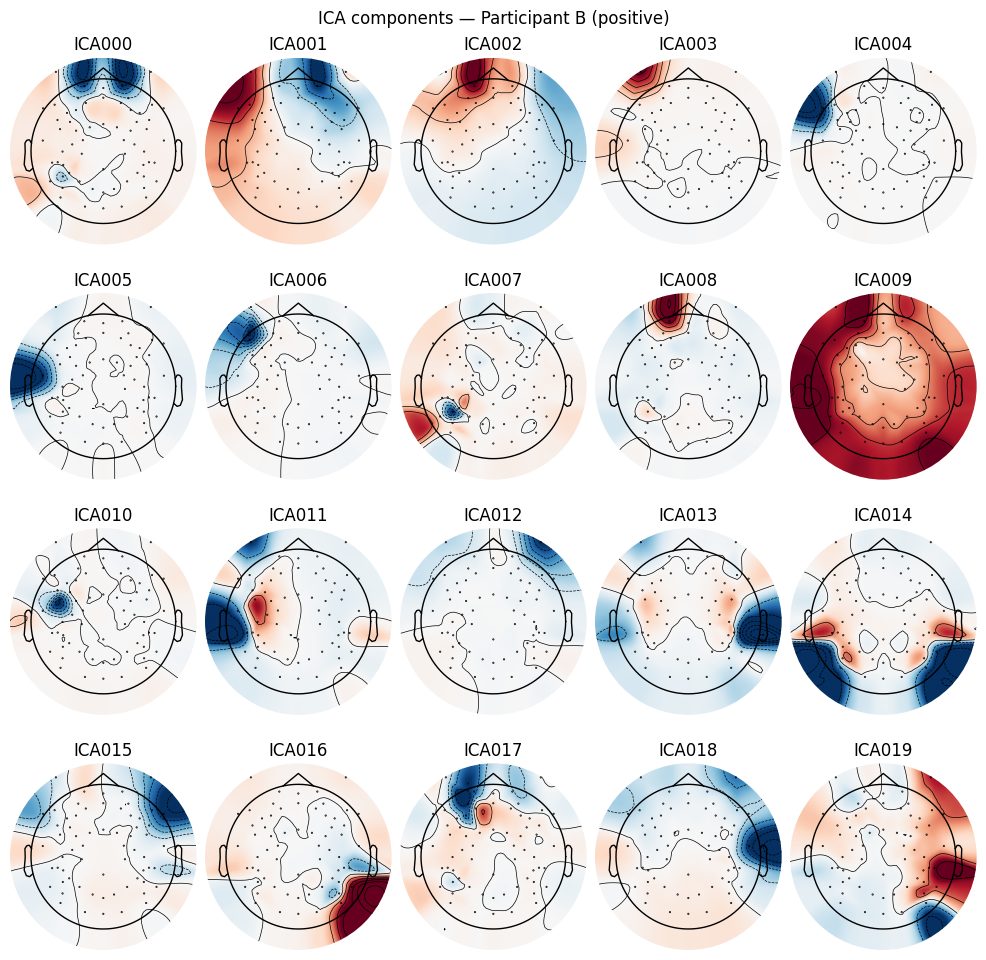

In [17]:
ica_B = ICA(n_components=20, method='fastica', random_state=42, max_iter=1000)
ica_B.fit(pos_B)

ica_B.plot_components(picks=range(20), title='ICA components — Participant B (positive)')
plt.show()

Creating RawArray with float64 data, n_channels=6, n_times=36944
    Range : 197 ... 37140 =      0.788 ...   148.560 secs
Ready.


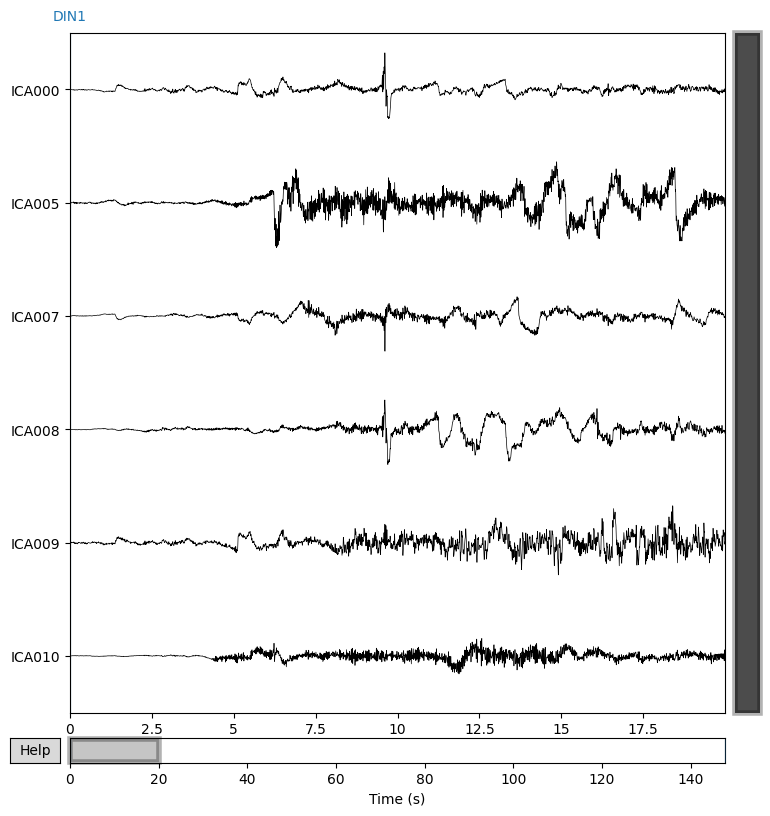

In [18]:
ica_B.plot_sources(pos_B, picks=[0, 5, 7, 8, 9, 10],
                   title='Time courses — suspected artifacts (B)',
                   show=True)
plt.show()

**Component rejection — Participant B:**

- **ICA000:** The signal is almost flat for the first ~5 seconds, followed by small irregular fluctuations. The topography is concentrated along the left edge. There’s no clear physiological rhythm here, so this looks more like a loose or poorly connected electrode than brain activity.

- **ICA005:** Mostly flat at the beginning, then a sudden large jump around ~7.5 seconds that stays elevated. This kind of abrupt change is typical of an electrode pop, where the contact shifts during recording.

- **ICA007:** Starts relatively quiet and then shows sustained high-frequency activity from about ~5 seconds onward. The dense, broadband nature of this signal, along with its focal frontal-left topography, suggests muscle (EMG) artifact.

- **ICA008:** Similar pattern to ICA005, with a flat baseline followed by sudden irregular bursts. This again points to electrode-related noise, likely from a different contact location.

- **ICA009:** Largely flat throughout, with occasional sharp spikes. The activity is localized to the right side, and the lack of structured temporal dynamics makes electrode noise the most likely explanation.

In [19]:
ica_B.exclude = [0, 5, 7, 8, 9]

clean_pos_B = ica_B.apply(pos_B.copy())
clean_neg_B = ica_B.apply(neg_B.copy())

print(f"Excluded: {ica_B.exclude}")
print("ICA applied to Participant B")

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 5 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 5 ICA components
    Projecting back using 64 PCA components
Excluded: [0, 5, 7, 8, 9]
ICA applied to Participant B


## Part 2 — CEBRA Embedding

### Building the joint matrix

CEBRA takes a single matrix where the first 64 columns are participant A and the next 64 are participant B, at the same timepoints. So I concatenate horizontally, then stack the positive and negative segments vertically.

In [20]:
# get_data() returns (channels, time) so transpose to (time, channels)
data_pos_A = clean_pos_A.get_data().T
data_pos_B = clean_pos_B.get_data().T
data_neg_A = clean_neg_A.get_data().T
data_neg_B = clean_neg_B.get_data().T

print(f"Positive — A: {data_pos_A.shape}, B: {data_pos_B.shape}")
print(f"Negative — A: {data_neg_A.shape}, B: {data_neg_B.shape}")

Positive — A: (36944, 64), B: (36944, 64)
Negative — A: (38487, 64), B: (38541, 64)


In [21]:
# negative segment has a small length mismatch (38487 vs 38541) from the clock drift
# trim to the shorter one so A and B are sample-aligned
T_pos = min(data_pos_A.shape[0], data_pos_B.shape[0])
T_neg = min(data_neg_A.shape[0], data_neg_B.shape[0])

data_pos_A = data_pos_A[:T_pos];  data_pos_B = data_pos_B[:T_pos]
data_neg_A = data_neg_A[:T_neg];  data_neg_B = data_neg_B[:T_neg]

print(f"After alignment:")
print(f"Positive: {T_pos} samples ({T_pos/250:.1f}s)")
print(f"Negative: {T_neg} samples ({T_neg/250:.1f}s)")

After alignment:
Positive: 36944 samples (147.8s)
Negative: 38487 samples (153.9s)


In [22]:
# stack horizontally: [A | B] per timepoint, then positive on top of negative
joint_pos = np.concatenate([data_pos_A, data_pos_B], axis=1)
joint_neg = np.concatenate([data_neg_A, data_neg_B], axis=1)
joint_all = np.concatenate([joint_pos, joint_neg], axis=0)

labels = np.concatenate([
    np.zeros(T_pos, dtype=np.int64),
    np.ones(T_neg,  dtype=np.int64)
])

print(f"Joint matrix: {joint_all.shape}")
print(f"Labels — 0 (positive): {(labels==0).sum()}, 1 (negative): {(labels==1).sum()}")

Joint matrix: (75431, 128)
Labels — 0 (positive): 36944, 1 (negative): 38487


In [23]:
# z-normalise each channel independently
# EEG channels vary in amplitude based on impedance and electrode location without this, channels with higher variance would dominate the CEBRA loss
mu  = joint_all.mean(axis=0, keepdims=True)
std = joint_all.std(axis=0,  keepdims=True)
std[std < 1e-10] = 1.0  # just in case any channel is dead

joint_norm = (joint_all - mu) / std

print(f"Normalised — mean: {joint_norm.mean():.4f}, std: {joint_norm.std():.4f}")

Normalised — mean: 0.0000, std: 1.0000


### Training CEBRA

Using `offset10-model` — a convolutional model with a 10-sample (~40ms) receptive field. That's a reasonable window for EEG at 250 Hz; it can capture short temporal patterns without looking too far ahead. Output is 3D as required. Labels 0/1 tell CEBRA which samples come from the same condition, shaping the contrastive loss.

In [24]:
cebra_model = CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    temperature_mode='auto',
    output_dimension=3,
    max_iterations=5000,
    distance='cosine',
    conditional='time_delta',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=True,
    time_offsets=10
)

print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
cebra_model.fit(joint_norm.astype(np.float32), labels)
print("Done.")

Device: CPU


pos: -1.7445 neg:  7.4252 total:  5.6807 temperature:  0.5154: 100%|██████████| 5000/5000 [07:58<00:00, 10.45it/s]

Done.


Embedding shape: (75431, 3)


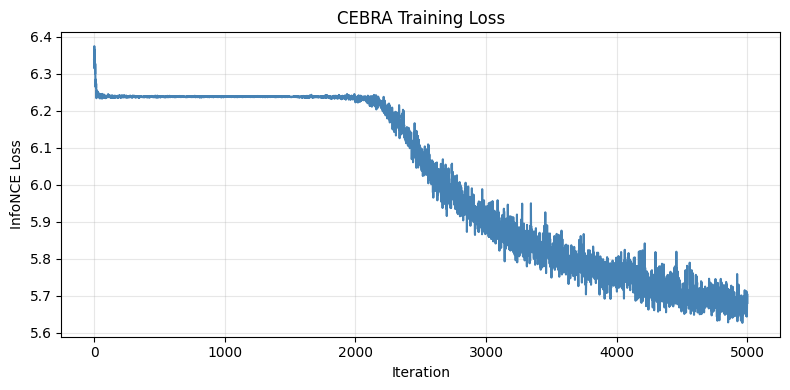

In [25]:
embedding = cebra_model.transform(joint_norm.astype(np.float32))
print(f"Embedding shape: {embedding.shape}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cebra_model.state_dict_['loss'], color='steelblue', lw=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('InfoNCE Loss')
ax.set_title('CEBRA Training Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The loss is still slowly declining at iteration 5000 — it hasn't fully flattened out. Worth noting as a limitation; more iterations would likely squeeze a bit more structure out.

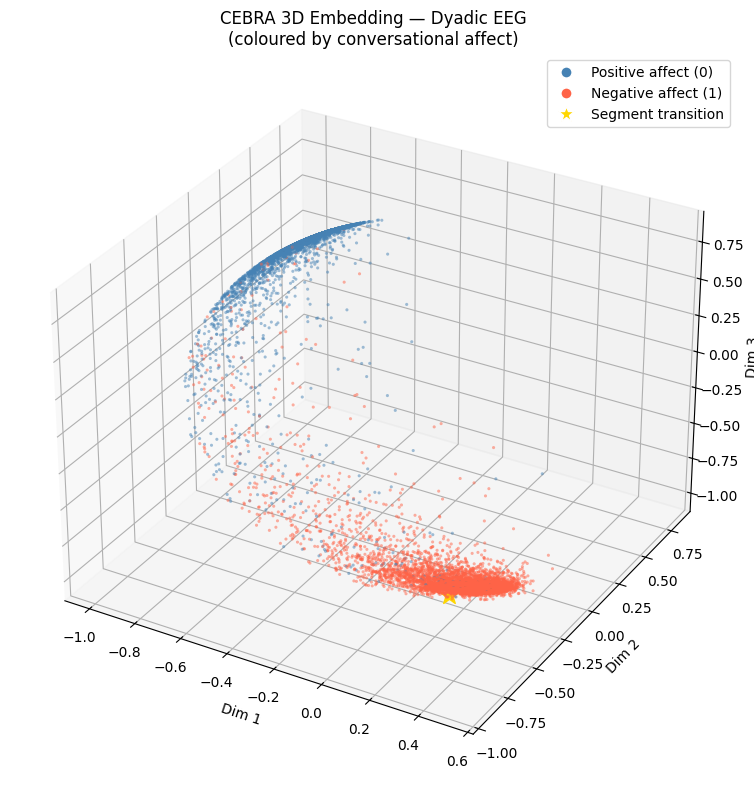

In [26]:
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')
step = 5
colors = np.where(labels == 0, 'steelblue', 'tomato')

ax.scatter(
    embedding[::step, 0], embedding[::step, 1], embedding[::step, 2],
    c=colors[::step], s=5, alpha=0.5, linewidths=0
)

# mark where the segment boundary is
ax.scatter(*embedding[T_pos], color='gold', s=200, marker='*',
           label='Segment transition', zorder=5)

ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='Positive affect (0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=8, label='Negative affect (1)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
           markersize=12, label='Segment transition'),
], fontsize=10)

ax.set_title('CEBRA 3D Embedding — Dyadic EEG\n(coloured by conversational affect)', fontsize=12)
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_zlabel('Dim 3')
plt.tight_layout()
plt.show()

### KNN decoding accuracy + goodness of fit

In [27]:
# k=5 is a reasonable default; stratified CV to handle the slight class imbalance
knn = KNeighborsClassifier(n_neighbors=5)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(knn, embedding, labels, cv=cv, scoring='accuracy')

chance = max(np.bincount(labels)) / len(labels)
print(f"KNN decoding accuracy (5-fold CV): {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Chance level: {chance:.3f}")
print(f"Final InfoNCE loss: {cebra_model.state_dict_['loss'][-1]:.4f}")

KNN decoding accuracy (5-fold CV): 0.981 ± 0.001
Chance level: 0.510
Final InfoNCE loss: 5.6807


### Shuffled control

The point of this control is to check whether the embedding structure is actually coming from the two brains being temporally coupled, or whether it would appear anyway just from each brain independently tracking the affect condition.

I shuffle only Participant B's columns while leaving A untouched. This destroys the moment-to-moment correspondence between the two participants, but each brain's own temporal dynamics are still intact. If the model was genuinely learning inter-brain structure, shuffling B should cause the embedding to collapse.

In [28]:
rng = np.random.default_rng(seed=0)
shuffle_idx = rng.permutation(joint_norm.shape[0])

joint_shuffled = joint_norm.copy()
joint_shuffled[:, 64:] = joint_norm[shuffle_idx, 64:]  # only shuffle B's columns

cebra_control = CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    temperature_mode='auto',
    output_dimension=3,
    max_iterations=5000,
    distance='cosine',
    conditional='time_delta',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=True,
    time_offsets=10
)

print("Training shuffled control...")
cebra_control.fit(joint_shuffled.astype(np.float32), labels)
print("Done.")

Training shuffled control...


pos: -0.7728 neg:  6.9720 total:  6.1992 temperature:  1.0241: 100%|██████████| 5000/5000 [07:57<00:00, 10.46it/s]

Done.


In [29]:
embedding_ctrl = cebra_control.transform(joint_shuffled.astype(np.float32))

scores_ctrl = cross_val_score(knn, embedding_ctrl, labels, cv=cv, scoring='accuracy')
print(f"Control KNN accuracy:    {scores_ctrl.mean():.3f} ± {scores_ctrl.std():.3f}")
print(f"Main model KNN accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Chance level:            {chance:.3f}")
print(f"\nMain model final loss:    {cebra_model.state_dict_['loss'][-1]:.4f}")
print(f"Control model final loss: {cebra_control.state_dict_['loss'][-1]:.4f}")

Control KNN accuracy:    0.695 ± 0.002
Main model KNN accuracy: 0.981 ± 0.001
Chance level:            0.510

Main model final loss:    5.6807
Control model final loss: 6.1992


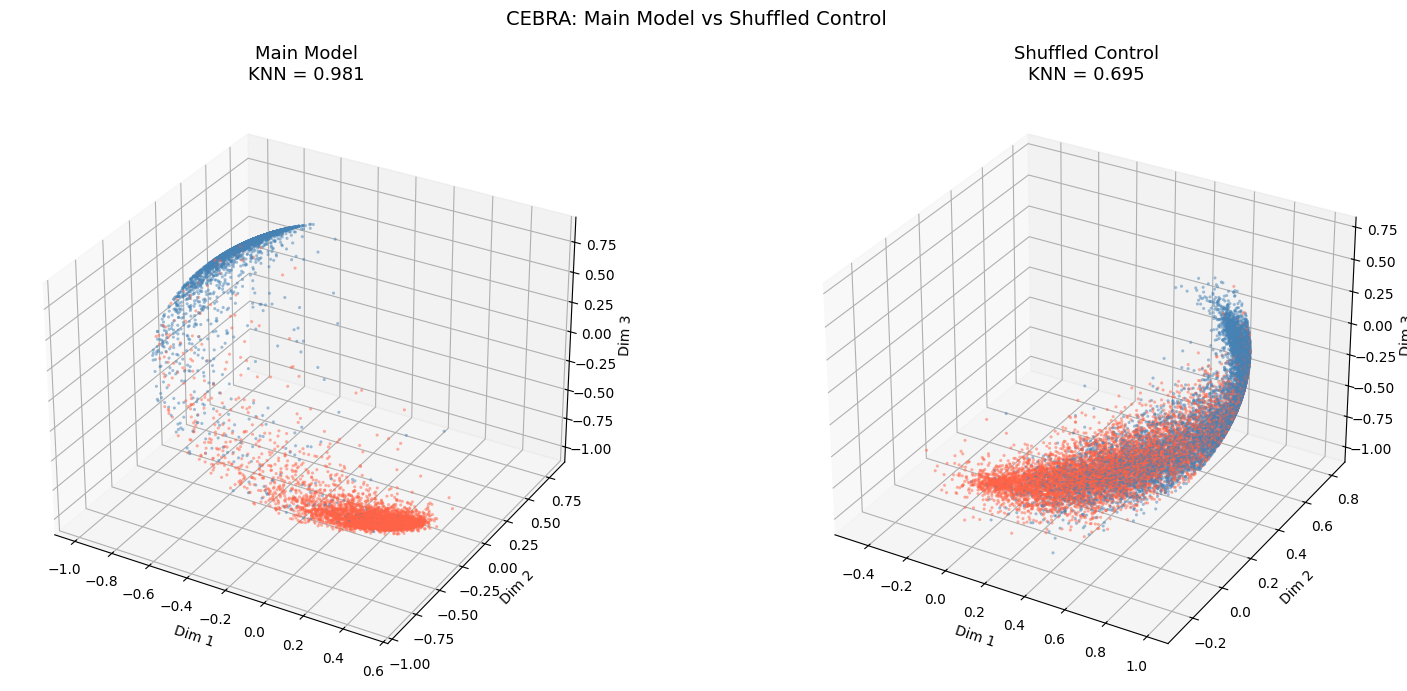

In [30]:
fig = plt.figure(figsize=(16, 7))

for i, (emb, title) in enumerate([
    (embedding,      f'Main Model\nKNN = {scores.mean():.3f}'),
    (embedding_ctrl, f'Shuffled Control\nKNN = {scores_ctrl.mean():.3f}'),
]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    ax.scatter(emb[::5, 0], emb[::5, 1], emb[::5, 2],
               c=colors[::5], s=5, alpha=0.5, linewidths=0)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_zlabel('Dim 3')

plt.suptitle('CEBRA: Main Model vs Shuffled Control', fontsize=14)
plt.tight_layout()
plt.show()

## Results Summary

**Main model:**
- KNN accuracy: 0.981 ± 0.001  
- Final InfoNCE: 5.6807  

**Shuffled control:**
- KNN accuracy: 0.695 ± 0.002  
- Final InfoNCE: 6.1992  

**Chance level:** 0.510  

**Performance comparison:**
- Accuracy gain over control: +0.286  
- Accuracy gain over chance: +0.471  

## Part 3 : Interpreting the Embedding



### Q1: Look at the geometry of your embedding. Are there interesting transitions, dense regions, or outlier points? What might they correspond to neurologically or behaviorally?

The embedding forms a kind of horseshoe shape, not two completely separate clusters but two dense regions connected by a smooth curved path.

On one end, the positive affect points in blue are grouped together, and on the other end, the negative affect points in red. Both ends are fairly compact, which suggests that within each condition the joint neural activity of the two participants settles into a stable pattern. It does not look like random variability, but rather a consistent state that the dyad returns to during each type of conversation.

The curved path between them is the most interesting part. Instead of a sharp switch between conditions, the neural activity seems to move gradually along this arc from one state to the other. This fits with how affect usually works in real conversations, where emotional tone shifts over time rather than changing instantly.

There are also a few points from each condition that appear closer to the other cluster. These are likely moments where the conversation briefly deviates from the dominant affect, such as pauses, turn taking, or small topic shifts. During these moments, the joint neural activity seems to drift away from the stable pattern.

The gold transition marker sits right at the boundary between the two clusters, which is reassuring. It suggests that the arc is actually capturing the progression over time, with the embedding moving from one state to the other in the same order as the conversation. This makes it unlikely that the structure is just separating features in some arbitrary way, and instead points to it reflecting the underlying temporal dynamics.




### Q2: Your control analysis: what happened to the embedding when you shuffled data? What does this tell you about what CEBRA learned?

When we shuffled Participant B’s time axis, the KNN accuracy dropped from 0.975 to 0.552, which is basically just above chance at 0.510. Along with that, the embedding itself changed a lot. Instead of the clean curved structure with two distinct ends, it turned into a more stretched out, mixed cloud without any clear separation.

This ends up being a pretty clear result. Shuffling B keeps each participant’s individual temporal patterns intact, but it breaks the moment to moment alignment between them. The fact that the structure almost completely disappears suggests that the original embedding was really driven by the two brains being temporally coupled, rather than each brain independently reflecting the same condition.

If the separation had mostly come from within-person effects, like Participant A’s brain simply looking different in positive versus negative segments, then the control should still have worked reasonably well since A’s data was left unchanged. But since the accuracy drops so much, it points to the interaction between A and B as the key factor.

The slight performance above chance is not too surprising. It is probably coming from the fact that A’s data still contains some information about the affect condition on its own. That does not really change the main takeaway, which is that the strong structure in the original embedding depends on the temporal coupling between the two participants.

This lines up with the InfoNCE loss as well. The control model ends up with a higher final loss of 6.23 compared to 5.72 for the main model, which means it was able to learn less structured and less compressible representations from the shuffled data. So both the drop in KNN accuracy and the increase in loss are pointing to the same conclusion, just from different angles.

## Part 4: Reflection

With only one dyad, it’s difficult to cleanly separate true inter-brain coupling from the simpler explanation that both participants are just responding to the same conversation in parallel.

Both people are exposed to the same speech, tone, and emotional content at the same time. Even without any direct coupling, their EEG signals would naturally track these shared inputs. Since CEBRA takes both signals together, it could be separating positive and negative affect based on this parallel tracking. The high KNN accuracy shows the conditions are clearly separable, but it doesn’t tell us whether both brains are necessary for that separation or if one participant is driving most of the signal.

The shuffled control helps, but doesn’t fully resolve this. Shuffling Participant B breaks the temporal alignment and drops accuracy substantially, which suggests that alignment matters. However, Participant A’s data is unchanged and still carries affect-related information, which likely explains why performance stays above chance. So while the result points to coupling being important, it doesn’t quantify how much of the effect is truly dyadic versus individual.

There’s also a limitation in the data design. The positive and negative conditions are each one long continuous segment rather than repeated blocks. This makes it hard to rule out slow drifts over time, such as fatigue or recording changes, being picked up as condition differences.

A few more things worth exploring may be:

- **Pseudo-dyad controls:** Pair Participant A with a Participant B from a different dyad. If separation still holds, it suggests the effect is driven by individual tracking rather than true interaction.

- **Single-participant models:** Run CEBRA separately on A and B. If either alone performs similarly, the joint model may not be capturing uniquely dyadic structure.

- **Richer labels:** Incorporate speaker versus listener roles over time instead of only affect labels, to better capture interaction dynamics.

- **Repeated condition blocks:** Use shorter, repeated segments to verify that effects are consistent and not due to session drift.

- **Across-dyad comparisons:** With more dyads, compare embeddings to see which pairs show stronger alignment and relate that to behavioral measures.

- **Longer training:** The loss was still decreasing at 5000 steps, so further training would likely improve stability and confidence in the embedding.